# 🎓 Sistema de Predivão de Risco Acadêmico

## Notebook 02 - Análise Exploratória e Ferature Engineering

# 1 - Introdução

Este notebook tem como objetivo realizar a análise exploratória dos dados
acadêmicos e a engenharia de atributos a partir das informações disponíveis
até o terceiro bimestre letivo.

O foco é preparar um conjunto de dados adequado para modelagem preditiva,
garantindo a ausência de vazamento de dados do período final do ano.


# 2 - Bibliotecas e Ferramentas Utilizadas

- python.
- pandas: manipulação e preparação dos dados
- numpy: operações numéricas e agregações
- matplotlib: visualizações exploratórias
- seabonr: visualizações exploratórias

# 3 - Importação de bibliotecas

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 4 - Importação dos dados

In [6]:
df = pd.read_csv("../data/raw/dados_academicos.csv")
df.head()

,id_aluno,idade,serie,prova_b1,trab1_b1,trab2_b1,freq_b1,prova_b2,trab1_b2,trab2_b2,...,trab1_b4,trab2_b4,freq_b4,nota_b1,nota_b2,nota_b3,nota_b4,nota_final,frequencia_final,resultado_final
0,1,13,6,6.5,0.2,0.3,77.7,5.9,0.1,0.3,...,0.2,0.7,77.9,7.0,6.3,6.3,4.8,6.100,72.70,Reprovado
1,2,14,7,3.8,0.3,0.1,75.2,7.0,0.1,0.3,...,0.4,0.1,52.9,4.2,7.4,4.7,4.9,5.300,77.70,Recuperação
2,3,11,6,5.9,0.2,0.4,59.7,6.8,0.9,0.1,...,0.6,0.2,84.8,6.5,7.8,6.2,4.6,6.275,65.80,Reprovado
3,4,13,6,6.0,0.4,0.3,92.9,3.8,0.2,0.7,...,0.8,0.8,52.6,6.7,4.7,5.5,5.6,5.625,72.85,Reprovado
4,5,13,7,5.1,0.1,0.7,83.8,3.7,0.8,0.0,...,0.9,0.5,90.9,5.9,4.5,9.0,9.3,7.175,77.60,Aprovado


# 5 - Análise Exploratória de Dados (EDA)

A análise exploratória abordará o conjunto completo de dados.
Entretanto, o modelo de Machine Learning utilizará apenas informações
dos três primeiros bimestres, simulando um cenário real de previsão
antes do encerramento do ano letivo.


In [15]:
# Resumo das variáveis presentes no DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id_aluno          800 non-null    int64  
 1   idade             800 non-null    int32  
 2   serie             800 non-null    int64  
 3   prova_b1          800 non-null    float64
 4   trab1_b1          800 non-null    float64
 5   trab2_b1          800 non-null    float64
 6   freq_b1           800 non-null    float64
 7   prova_b2          800 non-null    float64
 8   trab1_b2          800 non-null    float64
 9   trab2_b2          800 non-null    float64
 10  freq_b2           800 non-null    float64
 11  prova_b3          800 non-null    float64
 12  trab1_b3          800 non-null    float64
 13  trab2_b3          800 non-null    float64
 14  freq_b3           800 non-null    float64
 15  prova_b4          800 non-null    float64
 16  trab1_b4          800 non-null    float64
 1

Os dados estão conforme as instruções dadas na etapa de criação do dataset tanto para os tipos quanto para o número de variáveis e amostras.

A coluna "serie" está identificada pelo tipo int64, mas corresponde a uma variável categórica, no entanto, isso não deve gerar problemas ou erros durante a produção dos modelos.

In [7]:
# Exibição de variáveis descritivas para cada coluna numérica
pd.options.display.float_format = '{:.2f}'.format
df = pd.DataFrame (df)
df.describe()

,id_aluno,idade,serie,prova_b1,trab1_b1,trab2_b1,freq_b1,prova_b2,trab1_b2,trab2_b2,...,prova_b4,trab1_b4,trab2_b4,freq_b4,nota_b1,nota_b2,nota_b3,nota_b4,nota_final,frequencia_final
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,...,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,400.50,12.55,7.43,5.50,0.50,0.50,74.56,5.46,0.50,0.50,...,5.57,0.50,0.50,74.56,6.50,6.46,6.36,6.57,6.47,74.73
std,231.08,1.15,1.12,1.46,0.29,0.29,14.36,1.43,0.29,0.29,...,1.43,0.30,0.29,14.65,1.53,1.50,1.50,1.48,0.77,7.14
min,1.00,11.00,6.00,3.00,0.00,0.00,50.00,3.00,0.00,0.00,...,3.00,0.00,0.00,50.10,3.10,3.20,3.40,3.10,4.15,54.40
25%,200.75,12.00,6.00,4.20,0.30,0.30,61.68,4.20,0.30,0.20,...,4.40,0.20,0.20,61.80,5.20,5.20,5.10,5.40,5.92,69.69
50%,400.50,13.00,7.00,5.50,0.50,0.50,74.30,5.50,0.50,0.50,...,5.60,0.50,0.50,74.05,6.50,6.50,6.30,6.60,6.47,74.85
75%,600.25,14.00,8.00,6.70,0.70,0.80,87.40,6.62,0.70,0.72,...,6.80,0.80,0.80,87.22,7.80,7.60,7.60,7.80,7.00,79.57
max,800.00,14.00,9.00,8.00,1.00,1.00,100.00,8.00,1.00,1.00,...,8.00,1.00,1.00,99.90,9.70,9.70,9.90,9.70,8.70,94.60


Observa-se que o dataset não apresenta valores ausentes,
e que as variáveis numéricas estão dentro de intervalos coerentes
com o contexto escolar.


## 5.1 - Gráficos para comparação por da distribuição dentro da situação final de avaliação

### Comparação das notas bimestrais e final

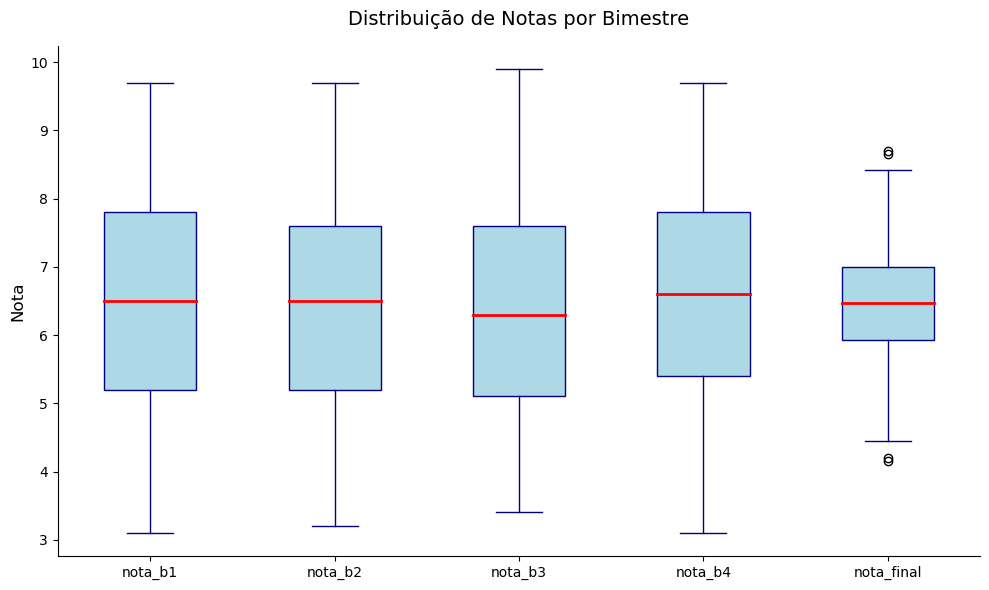

In [9]:
# Geração de um gráfico boxplot comparando a variação das notas bimestrais e final
fig, ax = plt.subplots(figsize=(10, 6))

# Selecionando colunas de nota
notas_cols = [c for c in df.columns if 'nota' in c]

# Gerando o boxplot estilizado
df.boxplot(column=notas_cols,
           ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='navy'),
           capprops=dict(color='navy'))


ax.grid(False) # Remove as linhas de grade

ax.set_title('Distribuição de Notas por Bimestre', fontsize=14, pad=15)
ax.set_ylabel('Nota', fontsize=12)
ax.spines['top'].set_visible(False)   # Remove borda superior
ax.spines['right'].set_visible(False) # Remove borda direita

plt.tight_layout()
plt.show()

Observa-se que as médias das notas bimestrais e da nota final são próximas,
com variação relativamente reduzida entre elas.

Ao longo dos bimestres, há maior dispersão das notas entre os alunos,
enquanto a nota final apresenta menor variabilidade, com poucos valores
extremos identificados como outliers fora dos limites interquartis.

### Comparação das frequências bimestrais e final

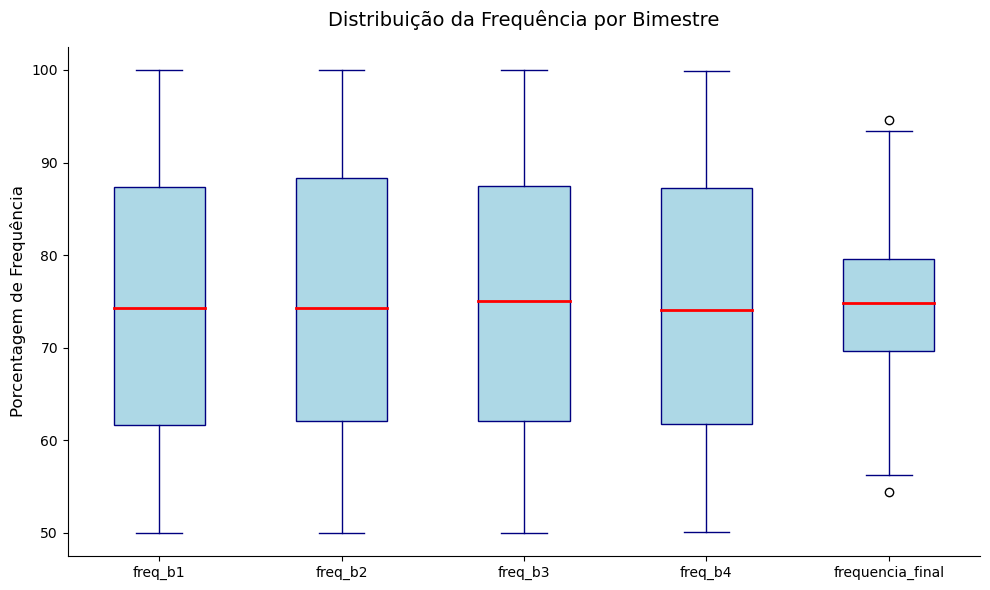

In [10]:
# Geração de um gráfico boxplot comparando a variação das frequências bimestrais e final
fig, ax = plt.subplots(figsize=(10, 6))

# Selecionando colunas de nota
notas_cols = [c for c in df.columns if 'freq' in c]

# Gerando o boxplot estilizado
df.boxplot(column=notas_cols,
           ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2),
           whiskerprops=dict(color='navy'),
           capprops=dict(color='navy'))


ax.grid(False) # Remove as linhas de grade

ax.set_title('Distribuição da Frequência por Bimestre', fontsize=14, pad=15)
ax.set_ylabel('Porcentagem de Frequência', fontsize=12)
ax.spines['top'].set_visible(False)   # Remove borda superior
ax.spines['right'].set_visible(False) # Remove borda direita

plt.tight_layout()
plt.show()

As médias das frequências bimestrais e final são próximas,
com variação relativamente reduzida entre elas.

Ao longo dos bimestres, há maior dispersão da frequência entre os alunos,
enquanto a frequência final apresenta menor variabilidade, com poucos valores
extremos identificados como outliers fora dos limites interquartis.

### Distribuição das notas por bimestre

In [11]:
notas_cols = [f'nota_b{b}' for b in range(1, 5)]
df[notas_cols].describe()

,nota_b1,nota_b2,nota_b3,nota_b4
count,800.00,800.00,800.00,800.00
mean,6.50,6.46,6.36,6.57
std,1.53,1.50,1.50,1.48
min,3.10,3.20,3.40,3.10
25%,5.20,5.20,5.10,5.40
50%,6.50,6.50,6.30,6.60
75%,7.80,7.60,7.60,7.80
max,9.70,9.70,9.90,9.70


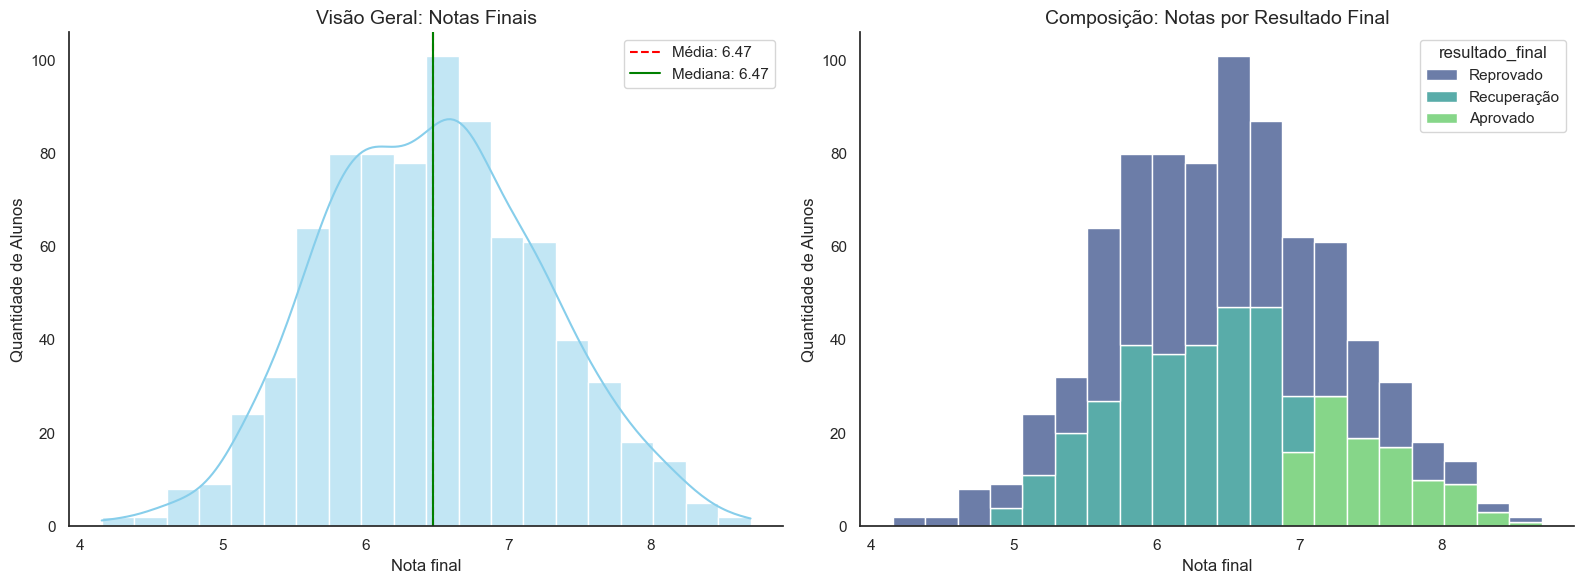

In [17]:
# Geração de um histograma da distribuição das notas finais por situação final dos alunos

# Configurações de estilo
sns.set_theme(style="white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de Distribuição Geral com Média e Mediana
sns.histplot(df['nota_final'], kde=True, color='skyblue', edgecolor='white', ax=ax1)
media = df['nota_final'].mean()
mediana = df['nota_final'].median()

ax1.axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
ax1.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')
ax1.set_title('Visão Geral: Notas Finais', fontsize=14)
ax1.set_ylabel('Quantidade de Alunos')
ax1.set_xlabel('Nota final')
ax1.legend()
ax1.grid(False)

# Histograma da Distribuição das notas por categoria de aprovação
sns.histplot(data=df, x='nota_final', hue='resultado_final', multiple="stack", 
             palette='viridis', ax=ax2, edgecolor='white')
ax2.set_title('Composição: Notas por Resultado Final', fontsize=14)
ax2.set_ylabel('Quantidade de Alunos')
ax2.set_xlabel('Nota final')
ax2.grid(False)

sns.despine()
plt.tight_layout()
plt.show()




As distribuições das notas apresentam formato aproximadamente normal,
com concentração em valores centrais e simetria moderada.

Embora o grupo de alunos na situação *Aprovado* seja numericamente menor,
suas notas também seguem um padrão de distribuição semelhante,
sem indícios fortes de assimetria ou multimodalidade.

### Distribuição da frequência por bimestre

In [18]:
freq_cols =[f'freq_b{b}' for b in range(1, 5)]
df[freq_cols].describe()

,freq_b1,freq_b2,freq_b3,freq_b4
count,800.00,800.00,800.00,800.00
mean,74.56,74.88,74.91,74.56
std,14.36,14.49,14.49,14.65
min,50.00,50.00,50.00,50.10
25%,61.68,62.10,62.10,61.80
50%,74.30,74.35,75.00,74.05
75%,87.40,88.30,87.53,87.22
max,100.00,100.00,100.00,99.90


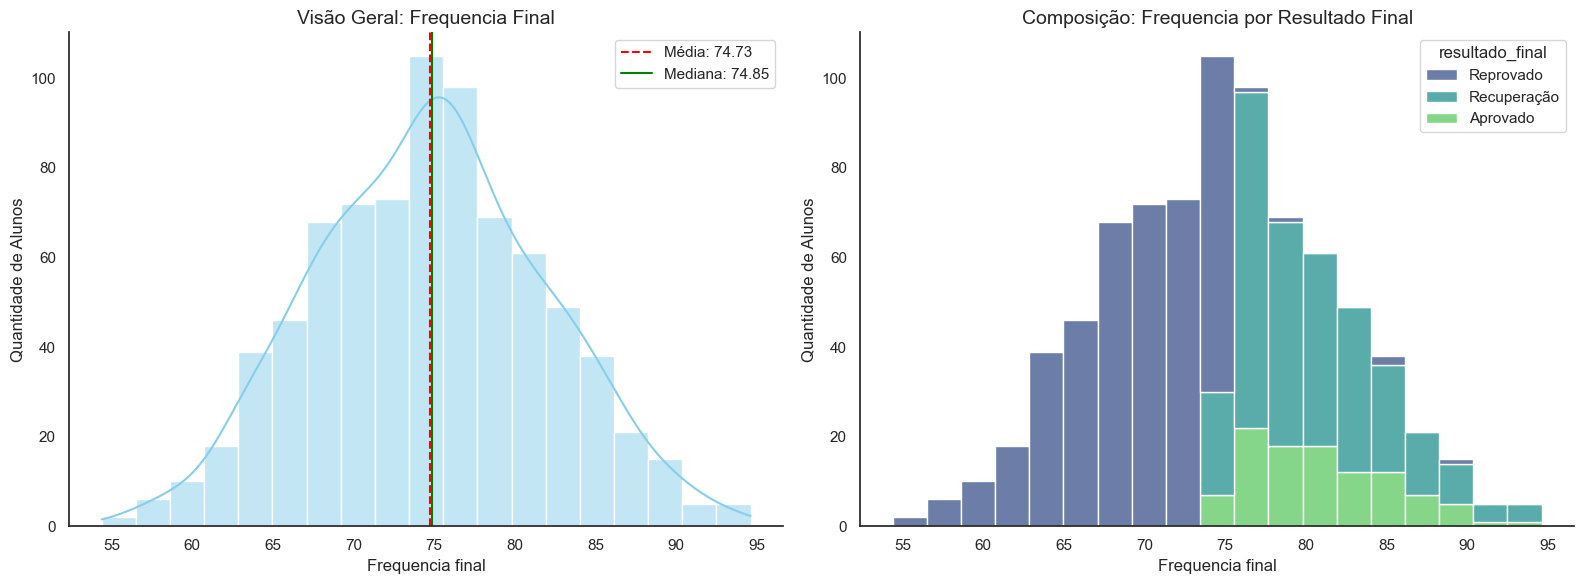

In [19]:
# Geração de um histograma da distribuição das frequências finais
# Configurações de estilo
sns.set_theme(style="white")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histograma de Distribuição das frequências com Média e Mediana
sns.histplot(df['frequencia_final'], kde=True, color='skyblue', edgecolor='white', ax=ax1)
media = df['frequencia_final'].mean()
mediana = df['frequencia_final'].median()

ax1.axvline(media, color='red', linestyle='--', label=f'Média: {media:.2f}')
ax1.axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')
ax1.set_title('Visão Geral: Frequencia Final', fontsize=14)
ax1.set_ylabel('Quantidade de Alunos')
ax1.set_xlabel('Frequencia final')
ax1.legend()
ax1.grid(False)

# Histograma da Distribuição das frequências por categoria de aprovação
sns.histplot(data=df, x='frequencia_final', hue='resultado_final', multiple="stack", 
             palette='viridis', ax=ax2, edgecolor='white')
ax2.set_title('Composição: Frequencia por Resultado Final', fontsize=14)
ax2.set_ylabel('Quantidade de Alunos')
ax2.set_xlabel('Frequencia final')
ax2.grid(False)

sns.despine()
plt.tight_layout()
plt.show()


As distribuições das frequências apresentam formato aproximadamente normal,
com concentração em valores centrais e simetria moderada.

## 5.2 - Correlações entre as variáveis

In [20]:
# Selecionando apenas as variáveis numéricas
colunas_numericas = df.select_dtypes(include=["float64", "int64"]).columns
# Remove colunas numéricas que não devem entrar na análise de correlação
colunas_numericas = colunas_numericas.drop(['id_aluno', 'serie'])  
corr = df[colunas_numericas].corr() # correlação

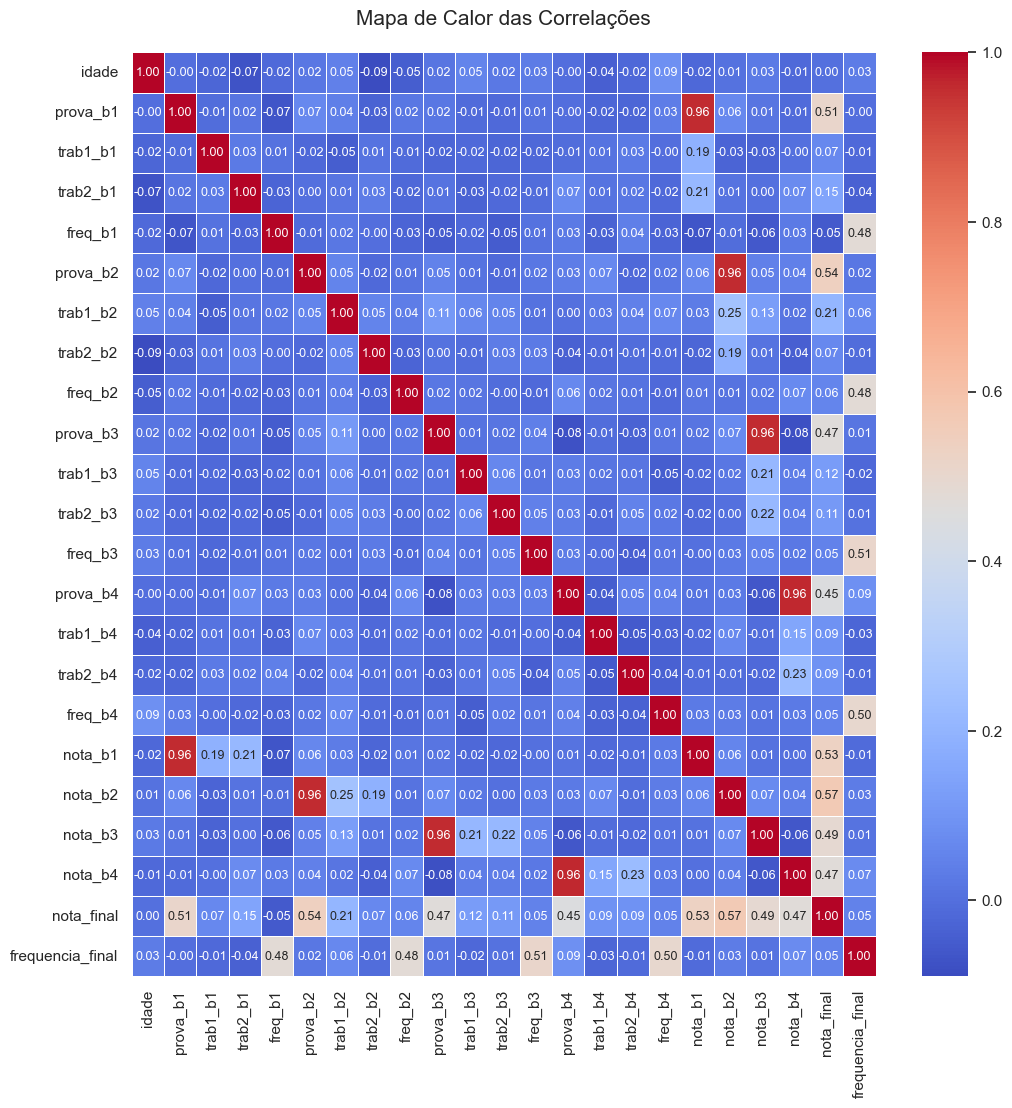

In [21]:
# Plotar as correlações em um mapa de calor 
plt.figure(figsize=(12, 12))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 9}
    )
plt.title('Mapa de Calor das Correlações', fontsize=15, pad=20)
plt.show()

As correlações mais elevadas ocorrem entre as notas das provas bimestrais
e as respectivas notas finais de cada bimestre. Esse comportamento é
esperado, uma vez que a prova representa aproximadamente 80% da composição
da nota bimestral.

De forma semelhante, a frequência final apresenta maior correlação apenas
com as variáveis de frequência por bimestre, refletindo sua construção
agregada ao longo do ano letivo.

As demais correlações são predominantemente fracas, com coeficientes
inferiores a 0,30, indicando baixa dependência linear entre essas variáveis.



## 5.3 - Distribuição dos dados entre as categorias de classse

### Situação final de aprovação

In [22]:
# Resultado final de aprovação
df['resultado_final'].value_counts(normalize=True)

Reprovado     0.52
Recuperação   0.35
Aprovado      0.13
Name: resultado_final, dtype: float64

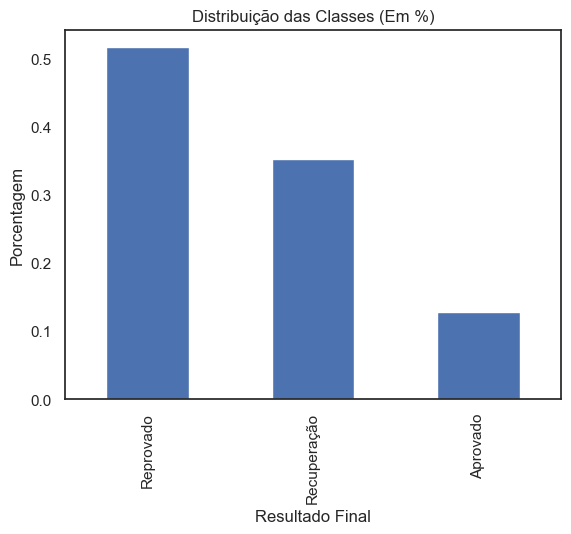

In [23]:
df['resultado_final'].value_counts(normalize=True).plot(
    kind='bar',
    title='Distribuição das Classes (Em %)',
    xlabel='Resultado Final',
    ylabel='Porcentagem'
    )
plt.show()

A distribuição dos alunos entre as classes do resultado final apresenta
desbalanceamento, o que pode impactar o treinamento dos modelos de
classificação.

Para mitigar esse efeito, foi adotada a utilização de pesos de classe
(`class_weight='balanced'`) durante o treinamento dos modelos,
estratégia que ajusta a penalização dos erros de acordo com a frequência
de cada classe.


### Alunos por série

In [24]:
# Proporção de alunos por série
df['serie'].value_counts(normalize=True)

6   0.27
7   0.25
8   0.25
9   0.23
Name: serie, dtype: float64

### Alunos por idade

In [25]:
# Proporção de alunos por idade
df['idade'].value_counts(normalize=True)

14   0.28
11   0.25
13   0.23
12   0.23
Name: idade, dtype: float64

A proporção de alunos está distribuída quase que uniformemente entre as séries e idades presentes no dataset. 

# 6 - Engenharia de features

Serão utilizados exclusivamente dados referentes aos três primeiros
bimestres, evitando qualquer vazamento de informação do quarto bimestre.

Além das variáveis originais, foram criadas quatro features derivadas com
base nesses três períodos:

- **slope_nota**: indica a tendência de evolução das notas ao longo dos
  bimestres (melhora ou queda no desempenho).
- **var_nota**: representa a variabilidade das notas, indicando o nível de
  constância do desempenho acadêmico do aluno.
- **media_nota_b1_b3**: média das notas obtidas nos três primeiros bimestres,
  resumindo o desempenho acadêmico acumulado.
- **media_freq_b1_b3**: média das frequências registradas nos três primeiros
  bimestres, refletindo o engajamento do aluno ao longo do período.

Essas variáveis fornecem uma visão consolidada do desempenho acadêmico do
aluno até o terceiro bimestre, alinhada ao objetivo de antecipar o risco
acadêmico antes do encerramento do ano letivo.


In [26]:
# Identificação e criação de features
 
df['slope_nota'] = df['nota_b3'] - df['nota_b1'] # calcula o slope das notas
df['var_nota'] = df[['nota_b1','nota_b2','nota_b3']].var(axis=1) # calcula a variância das notas 
df['media_nota_b1_b3'] = df[['nota_b1','nota_b2','nota_b3']].mean(axis=1) # calcula a média da nota entre os três bimestres
df['media_freq_b1_b3'] = df[['freq_b1','freq_b2','freq_b3']].mean(axis=1) # calcula a frequência dos alunos entre os três bimestres

features= [
    'prova_b1','prova_b2','prova_b3',
    'trab1_b1','trab1_b2','trab1_b3',
    'trab2_b1','trab2_b2','trab2_b3',
    'freq_b1','freq_b2','freq_b3',
    'idade','serie','media_nota_b1_b3','media_freq_b1_b3',
    'slope_nota','var_nota'
]

# 7 - Preparação de dados para modelagem

In [27]:
# Definição X
X= df[features]
y = df['resultado_final']

In [28]:
## Codificação da variável alvo

y = y.map({
    'Reprovado': 0,
    'Recuperação': 1,
    'Aprovado': 2
})


A variável alvo ("resultado_final"), originalmente categórica, foi codificada em valores
numéricos para viabilizar o treinamento dos modelos de classificação
multiclasse.

Essa transformação não altera o significado das classes, apenas adapta
a representação dos dados às exigências dos algoritmos utilizados.

In [29]:
# Visualização do dataset pronto para iniciar a modelagem
df_modelo = pd.concat([X, y.rename('resultado_final')], axis=1)
df_modelo.head()

,prova_b1,prova_b2,prova_b3,trab1_b1,trab1_b2,trab1_b3,trab2_b1,trab2_b2,trab2_b3,freq_b1,freq_b2,freq_b3,idade,serie,media_nota_b1_b3,media_freq_b1_b3,slope_nota,var_nota,resultado_final
0,6.50,5.90,4.80,0.20,0.10,0.70,0.30,0.30,0.80,77.70,84.20,51.00,13,6,6.53,70.97,-0.70,0.16,0
1,3.80,7.00,3.70,0.30,0.10,0.70,0.10,0.30,0.30,75.20,94.10,88.60,14,7,5.43,85.97,0.50,2.96,1
2,5.90,6.80,5.60,0.20,0.90,0.10,0.40,0.10,0.50,59.70,60.20,58.50,11,6,6.83,59.47,-0.30,0.72,0
3,6.00,3.80,3.60,0.40,0.20,0.90,0.30,0.70,1.00,92.90,93.70,52.20,13,6,5.63,79.60,-1.20,1.01,0
4,5.10,3.70,7.70,0.10,0.80,0.60,0.70,0.00,0.70,83.80,53.00,82.70,13,7,6.47,73.17,3.10,5.30,2


In [30]:
# Salvar o dataset pronto para modelagem
df_modelo.to_csv("../data/processed/dados_academicos_processados.csv")


# 8 - Conclusão

Foram realizadas análises exploratórias e criadas variáveis agregadas
representativas do desempenho dos alunos até o terceiro bimestre.
O dataset final foi preparado para utilização em modelos de Machine Learning,
respeitando as boas práticas de engenharia de atributos.


# 9 - Próximas etapas

Modelagem e avaliação dos modelos.